In [ ]:
# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Added for graphing
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
print("Student Roll No:24BAD026")

Student Roll No:24BAD026


In [ ]:
# 2. Load Breast Cancer dataset
print("Loading Breast Cancer dataset...")
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

# 3. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Loading Breast Cancer dataset...


In [ ]:
# 4. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Design ANN
model_clf = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid activation for binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 6. Compile model
# Binary crossentropy is standard for binary classification
model_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Train model
print("Training the classification model...")
history_clf = model_clf.fit(X_train_scaled, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=0)

# 8. Predict labels
# Predict probabilities, then threshold at 0.5 to get binary classes 0 or 1
print("Generating predictions...")
y_pred_probs = model_clf.predict(X_test_scaled)
y_pred_classes = (y_pred_probs > 0.5).astype(int)

Training the classification model...
Generating predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step



--- Classification Model Evaluation ---
Accuracy: 0.9737
Precision: 0.9595
Recall: 1.0000
F1-score: 0.9793
Confusion Matrix:
 [[40  3]
 [ 0 71]]


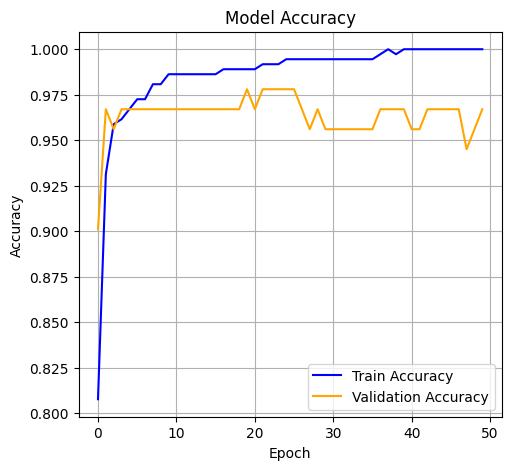

In [ ]:
# 9. Evaluate (Accuracy, Precision, Recall, F1-score, Confusion Matrix)
acc = accuracy_score(y_test, y_pred_classes)
prec = precision_score(y_test, y_pred_classes)
rec = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)
conf_matrix = confusion_matrix(y_test, y_pred_classes)

print("\n--- Classification Model Evaluation ---")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

# 10. Plot Training History (Graphs)
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_clf.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_clf.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

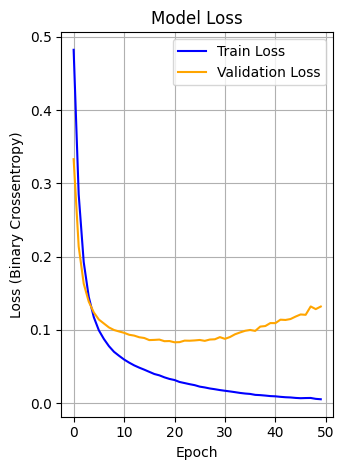

In [ ]:
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_clf.history['loss'], label='Train Loss', color='blue')
plt.plot(history_clf.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()